### Imports

In [ ]:
import csv
import pandas as pd
import numpy as np
import datetime
import holidays
import calendar
import torch
from torch import nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, random_split
import torch.utils.data as data_utils
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

### Global Parameters

In [ ]:
# NN params
epochs = 30
LR = 0.005
MOMENTUM = 0.9
batch_size = 32

### Loading Data

In [ ]:
path = r'./content/data.xlsx'

window = 16  # 1 week historical data
pred = 6    # will predict load demand 24 hr early

scaler = MinMaxScaler(feature_range=(-1, 1))

# Custom dataset class
class TimeSeriesDataset(Dataset):
  """
  The class takes csv data and stores it as pandas dataframe
  """
  def __init__(self, file_path, window, pred, train=True):
    """
    file_path: path of csv file containing data
    window: number of historical data being used to predict
    pred: time after which to predict(we pred 24hr in future)
    """
    data = pd.read_excel(file_path)
    data = data[data['Hour'].isin(range(8,24))] # delete all the times from 0 - 7
    data = data.reset_index(drop=True)

    sum_load = np.zeros(16)
    found_load = np.zeros(16)

    for i in range(0, data.shape[0]):
      if np.float32(data.at[i, 'T_av']) < 0:
        data.at[i, 'T_av'] = 20.0 - 4*np.random.rand()
      if np.float32(data.at[i, 'RH']) < 0:
        data.at[i, 'RH'] = 93.0 -  5*np.random.rand()
      if np.float32(data.at[i, 'Precep']) < 0:
        data.at[i, 'Precep'] = 0
      if np.float32(data.at[i, 'WindSpeed']) < 0:
        data.at[i, 'WindSpeed'] = 4.5 - 2*np.random.rand()
      if pd.isnull(data.at[i, 'Total Load']) == False:
        hour = np.int64(data.at[i, 'Hour'])
        load = np.float32(data.at[i, 'Total Load'])
        sum_load[hour-8] += load
        found_load[hour-8] += 1

    avg_load = np.divide(sum_load, found_load);

    for i in range(0, data.shape[0]):
      if pd.isnull(data.at[i, 'Total Load']) == True:
        hour = np.int64(data.at[i, 'Hour'])
        data.at[i, 'Total Load'] = np.int64(np.floor(avg_load[hour-8])) - np.random.randint(-20,20)


    self.data = self.preprocess(data.values)
    self.window = window  # duration taken in a single sample
    self.pred = pred

  def __len__(self):
    """ Returns number of samples """
    return len(self.data) - self.window -self.pred

  def __getitem__(self, idx):
    """ Gets one sample at each call at index idx """
    ss1 = self.data[idx:idx + self.window, -1].view(1, -1)  # data of historical load(24hr load of previous day for instance)
    sub_sample2 = self.data[idx + self.window + self.pred, :]
    *ss2, load = sub_sample2  # load is to predict
    ss2 = torch.tensor(ss2)

    return (ss1, ss2), load  #separate sample since different part will enter different nn

  def preprocess(self, data):

    data = data.astype('float32')
    data = torch.from_numpy(data)

    # one-hot encoding:
    months = nn.functional.one_hot(data[:, 1].to(torch.int64))
    # convert days of month to days of week:
    days = self.from_date_2_weekly_day(data[:, 0:3].to(torch.int64))
    hours = nn.functional.one_hot(data[:, 3].to(torch.int64))

    # process continuous variables: (temp,...)
    temp = data[:, 4].view(-1, 1)
    load = data[:, -1].view(-1, 1)
    cont_data = torch.cat((temp, load), dim=1)
    cont_data_processed = torch.tensor(scaler.fit_transform(cont_data), dtype=torch.float32)

    # concat them all
    processed_data = torch.cat((months, days, hours, cont_data_processed), dim=1)

    return processed_data

  def from_date_2_weekly_day(self, dates):
    day_names = { 'Saturday': 0,
                  'Sunday': 1,
                  'Monday': 2,
                  'Tuesday': 3,
                  'Wednesday': 4,
                  'Thursday': 5,
                  'Friday': 6
                  }
    holiday = holidays.Bangladesh(years = 2015)
    days = torch.zeros((len(dates), 2))  # 1st col: weekday, 2nd col: holiday?
    for i, date in enumerate(dates):
      date = datetime.date(*date)
      day_name = calendar.day_name[date.weekday()]
      day_name_idx = day_names[day_name]
      is_holiday = 1 if date in holiday else 0
      days[i, 0] = day_name_idx
      days[i, 1] =  is_holiday

      # hot encoding
    day_hot = nn.functional.one_hot(days[:, 0].to(torch.int64))
    holiday_hot = days[:, 1].to(torch.int64).view(-1, 1)
    day_holi = torch.cat((day_hot, holiday_hot), 1)

    return day_holi


dataset = TimeSeriesDataset(path, window, pred)

## Train Validation split

In [ ]:
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train_set, valid_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size = 168, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size = 168, shuffle=False)

### Model

In [ ]:
from pandas.io.formats.style import Axis

out_channel= 16   # number of kernels
feature_num = out_channel  # length of xt: load value
sequence_len =  24 # num of time step: 24 hour data of 1 day ago
hidden_len = 3
batch_size = 2
lstm_layer = 2  # depth of lstm layers
in_channel=1
kernel_size = [3, 5, 7]

# Linear module param
in_features = 46
out_features = 4

class BigNet(nn.Module):
  def __init__(self):
    super(BigNet, self).__init__()

    # 3 x CONV => RELU => POOL layers
    self.conv1 = nn.Conv1d(in_channel, out_channel, kernel_size=kernel_size[0])
    self.pool1 = nn.MaxPool1d(kernel_size=2)

    self.conv2 = nn.Conv1d(in_channel, out_channel, kernel_size[1])
    self.pool2 = nn.MaxPool1d(kernel_size=2)

    self.conv3 = nn.Conv1d(in_channel, out_channel, kernel_size[2])
    self.pool3 = nn.MaxPool1d(kernel_size=2)

    self.lstm = nn.LSTM(input_size=feature_num,
                        hidden_size=hidden_len,
                        num_layers=lstm_layer,
                        dropout=0.2,
                        batch_first=True)


    self.lin1 = nn.Linear(in_features, out_features)
    self.lin2 = nn.Linear(7, 1)
    # self.lin3 = nn.Linear()

    self.relu = nn.ReLU()


  def forward(self, s):
    """
    s (samples) = (ss1 ss2)
    ss1 = historical data
    ss2 = side data of target hour
    """
    ss1, ss2 = s  # ss1/2 are 2 tensors (N, Ch, datalen)
    x1 = self.conv1(ss1)
    x1 = self.relu(x1)
    x1 = self.pool1(x1)

    x2 = self.conv2(ss1)
    x2 = self.relu(x2)
    x2 = self.pool2(x2)

    x3 = self.conv3(ss1)
    x3 = self.relu(x3)
    x3 = self.pool3(x3)

    # concat x1 x2 x3
    x = torch.cat((x1, x2, x3), 2)
    x = x.permute(0, 2, 1)
    # LSTM:
    h0 = torch.randn((lstm_layer, x.shape[0], hidden_len))
    c0 = torch.randn((lstm_layer, x.shape[0], hidden_len))

    x, _ = self.lstm(x, (h0, c0))

    x = torch.mean(x, 1)

    ## 2nd branch
    z = self.lin1(ss2)
    z = self.relu(z)

    # branches converges:
    X = torch.cat((x, z), 1)

    X = self.lin2(X)
    # X = self.relu(X)
    # out = self.lin3(X)
    # out = self.relu(X)

    return X

### Training

/usr/local/lib/python3.8/dist-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([168])) that is different to the input size (torch.Size([168, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.8/dist-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([23])) that is different to the input size (torch.Size([23, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.8/dist-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([147])) that is different to the input size (torch.Size([147, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, t

{'epoch': 0, 'Training loss': 0.05489257350564003}
{'epoch': 1, 'Training loss': 0.05592995509505272}
{'epoch': 2, 'Training loss': 0.05686546117067337}
{'epoch': 3, 'Training loss': 0.05573058873414993}
{'epoch': 4, 'Training loss': 0.055256351828575134}
{'epoch': 5, 'Training loss': 0.054717157036066055}
{'epoch': 6, 'Training loss': 0.05524299293756485}
{'epoch': 7, 'Training loss': 0.05559302493929863}
{'epoch': 8, 'Training loss': 0.055597200989723206}
{'epoch': 9, 'Training loss': 0.054862890392541885}
{'epoch': 10, 'Training loss': 0.05530708655714989}
{'epoch': 11, 'Training loss': 0.054708924144506454}
{'epoch': 12, 'Training loss': 0.05553765222430229}
{'epoch': 13, 'Training loss': 0.05461028590798378}
{'epoch': 14, 'Training loss': 0.05528459697961807}
{'epoch': 15, 'Training loss': 0.055687449872493744}
{'epoch': 16, 'Training loss': 0.05492546036839485}
{'epoch': 17, 'Training loss': 0.05507441237568855}
{'epoch': 18, 'Training loss': 0.0553053617477417}
{'epoch': 19, 'Tr

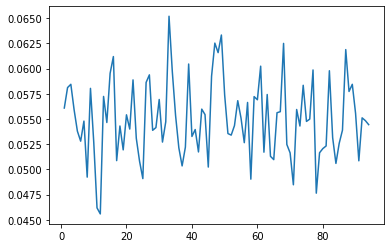

In [ ]:
epochs = 30

def train(train_loader, valid_loader, model):
  criterion = nn.L1Loss()  # MAE
  optimizer = torch.optim.RMSprop(model.parameters(), lr=LR, momentum=MOMENTUM)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,  patience=500,factor =0.5 ,min_lr=1e-7, eps=1e-08)
  for epoch in range(epochs):

    losses_tr = []   # loss of training
    model.train()  # tells the model it being trained

    for batch, (x, y) in enumerate(train_loader):
      # if batch > 40:
      #   break
      loss_pb = 0   # loss per batch
      optimizer.zero_grad()  # set grad of each param to zero
      y_pred = model(x)
      loss = criterion(y_pred, y)  # .transpose(1, 2)

      loss.backward()
      optimizer.step()
      loss_pb += loss.item()
      losses_tr.append(loss_pb)

    losses_val = []
    model.eval()

    for batch, (x, y) in enumerate(valid_loader):
      # loss_pb = 0
      # if 1==1:
      #   break
      loss_pb = 0
      valid = model(x)
      valid_loss = criterion(valid, y)
      scheduler.step(valid_loss)
      loss_pb += valid_loss.item()
      losses_val.append(loss_pb)
    print({ 'epoch': epoch, 'Training loss': losses_tr[len(losses_tr)-1]}) # 'Validation loss': losses_val[len(losses_val)-1]})


  # plot data
  print(losses_tr, losses_val)
  plt.plot(range(1, len(losses_tr) + 1), losses_tr)
  # plt.plot(range(1, len(losses_val) + 1), losses_val)
  plt.show()
  return model


model = BigNet()

model = train(train_loader, valid_loader, model)



### Prediction

In [ ]:
@torch.no_grad()  # decorator to turn off gradiant to reduce memory requirement
def predict(data_loader, model):
  model.eval()

  mae = 0
  mape = 0
  for batch, (x, y) in enumerate(data_loader):
    y_pred = model(x)

    # inverse normalize
    data_pred = scaler.inverse_transform(y_pred)
    data_true = scaler.inverse_transform(y)

    mae += torch.sum(torch.abs(data_pred - data_true))
    mape += torch.sum(abs(data_pred - data_true) / data_true)
  num_of_data = len(dataset)
  mae /= num_of_data
  mape /= num_of_data

  return (mae, mape)

mae, mape = predict(train_loader, model)

## Post Processing

In [ ]:
# to make prediction meaningful

# Rough stuff

In [ ]:
from datetime import date
import holidays

# Select country
bd_holidays = holidays.Bangladesh()

# Print all the holidays in UnitedKingdom in year 2018
for ptr in holidays.Bangladesh(years = 2018).items():
    print(ptr)

(datetime.date(2018, 2, 21), "International Mother's language Day")
(datetime.date(2018, 3, 17), "Sheikh Mujibur Rahman's Birthday and Children's Day")
(datetime.date(2018, 3, 26), 'Independence Day')
(datetime.date(2018, 4, 14), "Bengali New Year's Day")
(datetime.date(2018, 5, 1), 'May Day')
(datetime.date(2018, 8, 15), 'National Mourning Day')
(datetime.date(2018, 12, 16), 'Victory Day')


In [ ]:
#onehot encoding
    months = torch.zeros((data.shape[0], 12))
    for i in range(data.shape[0]):
      months[i, int(data[i, 0])-1] = 1


    days = torch.zeros((data.shape[0], 7))
    for i in range(data.shape[0]):
      days[i, int(data[i, 1])-1] = 1

    hours = torch.zeros((data.shape[0], 24))
    for i in range(data.shape[0]):
      hours[i, int(data[i, 2])-1] = 1
